#**Importación de Librerías**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#Creación de una imágen y un kernel

In [ ]:
#Creación de la imágen
imagen = np.array([
    [1, 2, 3, 0, 1],
    [0, 1, 2, 3, 1],
    [3, 1, 0, 2, 2],
    [2, 3, 1, 0, 0],
    [1, 2, 2, 1, 3]
    ])

#Creación del kernel

kernel = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
])

#**Función de Convolusión Manual**

In [18]:

def convolucion(imagen, kernel, stride=1, padding=0):

  #padding

  if padding>0:
    imagen=np.pad(imagen, pad_width=padding, mode='constant', constant_values=0)

  k_h, k_w=kernel.shape
  i_h, i_w=imagen.shape

  #Dimensión de Salida

  out_h=(i_h-k_h)//stride+1
  out_w=(i_w-k_w)//stride+1

  salida=np.zeros((out_h, out_w))

  for i in range(0, out_h):
    for j in range(0, out_w):
      region=imagen[i*stride:i*stride+k_h, j*stride:j*stride+k_w]
      salida[i, j]=np.sum(region * kernel)
  return salida

#Ejercicio 1 sin Padding

In [19]:
output_sin_padding = convolucion(imagen, kernel, stride=1, padding=0)

print("Sin padding:")
print(output_sin_padding)

Sin padding:
[[-1. -1.  1.]
 [ 2.  0.  0.]
 [ 3.  3. -2.]]


#Ejercicio 2 Con Padding

In [20]:
output_con_padding=convolucion(imagen, kernel, stride=1, padding=1)

print("\nCon Padding: ")
print(output_con_padding)


Con Padding: 
[[-3. -4.  0.  3.  3.]
 [-4. -1. -1.  1.  5.]
 [-5.  2.  0.  0.  5.]
 [-6.  3.  3. -2.  3.]
 [-5.  0.  4.  0.  1.]]


#Ejercicio 3 Cambio de stride

In [21]:
output_stride=convolucion(imagen, kernel, stride=2, padding=0)

print("\nConStride=2: ")
print(output_stride)


ConStride=2: 
[[-1.  1.]
 [ 3. -2.]]


#Visualización

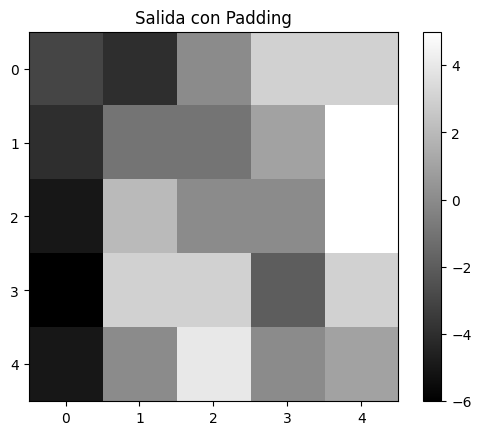

In [22]:
plt.imshow(output_con_padding, cmap='gray')
plt.title("Salida con Padding")
plt.colorbar()
plt.show()